In [1]:
# silence warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

In [2]:
%pip install opencv-python -q
%pip install keras_cv -q
%pip install pycocotools -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import keras
import keras_cv
from keras.callbacks import ModelCheckpoint
from keras_cv import visualization

In [4]:
# ensure access to GPU
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## read in and get data in the right format

In [5]:
# map CSV class names to IDs
class_mapping = {'bull': 0, 'cow': 1, 'pup': 2}

def load_dataset(csv_path, img_dir):
    df = pd.read_csv(csv_path, names=['file', 'x1', 'y1', 'x2', 'y2', 'label', 'extra'])
    
    # group by filename to get all boxes for one image together
    grouped = df.groupby('file')
    
    image_paths = []
    all_boxes = []
    all_classes = []
    
    for file, group in grouped:
        image_paths.append(f"{img_dir}/{file}")
        # x1, y1, x2, y2 -> x, y, w, h
        boxes = group[['x1', 'y1', 'x2', 'y2']].values
        boxes[:, 2] = boxes[:, 2] - boxes[:, 0] # width = x2 - x1
        boxes[:, 3] = boxes[:, 3] - boxes[:, 1] # height = y2 - y1
        
        all_boxes.append(boxes.astype('float32'))
        all_classes.append(group['label'].map(class_mapping).values.astype('float32'))

    # Create a TF Dataset
    def load_image(path, boxes, classes):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.cast(img, tf.float32)
        
        # ensure both are explicitly tensors so the dictionary is consistent
        return {
            "images": img, 
            "bounding_boxes": {
                "boxes": tf.cast(boxes, tf.float32), 
                "classes": tf.cast(classes, tf.float32)
            }
        }

    dataset = tf.data.Dataset.from_generator(
        lambda: zip(image_paths, all_boxes, all_classes),
        output_signature=(
            tf.TensorSpec(shape=(), dtype=tf.string),
            tf.TensorSpec(shape=(None, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.float32),
        )
    ).map(load_image)
    
    return dataset

# helper to turn Ragged boxes into Dense (padded) boxes
def pad_to_dense(data):
    boxes = data["bounding_boxes"]["boxes"]
    classes = data["bounding_boxes"]["classes"]
    
    # 1. Convert RaggedTensors to standard Tensors if they are ragged
    if isinstance(boxes, tf.RaggedTensor):
        boxes = boxes.to_tensor(default_value=-1.0)
    if isinstance(classes, tf.RaggedTensor):
        classes = classes.to_tensor(default_value=-1.0)

    # 2. Determine current number of boxes
    # We use tf.shape(boxes)[0] to handle the dynamic dimension
    num_boxes = tf.shape(boxes)[0]
    pad_len = tf.maximum(0, 32 - num_boxes)
    
    # 3. Pad boxes to (32, 4)
    padded_boxes = tf.pad(boxes, [[0, pad_len], [0, 0]], constant_values=-1.0)
    padded_boxes = padded_boxes[:32, :] # Ensure exactly 32
    
    # 4. Pad classes to (32,)
    # We ensure classes is 1D before padding
    classes = tf.reshape(classes, [-1])
    padded_classes = tf.pad(classes, [[0, pad_len]], constant_values=-1.0)
    padded_classes = padded_classes[:32] # Ensure exactly 32
    
    # 5. Set static shapes so the Batching layer is happy
    padded_boxes.set_shape([32, 4])
    padded_classes.set_shape([32])
    
    data["bounding_boxes"] = {
        "boxes": padded_boxes,
        "classes": padded_classes
    }
    return data

# map the dataset to the format the model expects: (input_dict, target_dict)
def prepare_for_model(data):
    # x: The raw image tensor (RetinaNet extracts features from this)
    # y: The bounding box dictionary (LabelEncoder uses this to create targets)
    return data["images"], data["bounding_boxes"]

In [6]:
train_csv = 'data/train/annotations_final_no.csv'
valid_csv = 'data/valid/annotations_final_no.csv'
train_dir = 'data/train'
valid_dir = 'data/valid'

train_ds = load_dataset(train_csv, train_dir)
val_ds = load_dataset(valid_csv, valid_dir)

I0000 00:00:1772583327.223424     804 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10697 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [7]:
augmenter = keras.Sequential([
    keras_cv.layers.RandomFlip(mode="horizontal", bounding_box_format="xywh"),
    keras_cv.layers.JitteredResize(
        target_size=(640, 640),
        scale_factor=(0.7, 1.3), # Zoom in and out on the seals
        bounding_box_format="xywh"
    ),
])

# Apply to train_ds only (don't augment validation!)
train_ds = train_ds.map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)

In [8]:
# resize, handling RaggedTensors correctly
resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

In [9]:
train_ds = (
    train_ds
    .map(resizing, num_parallel_calls=tf.data.AUTOTUNE)
    .map(pad_to_dense, num_parallel_calls=tf.data.AUTOTUNE) # Pad boxes here!
    .batch(8) # Standard batching now works
    .map(prepare_for_model, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(resizing, num_parallel_calls=tf.data.AUTOTUNE)
    .map(pad_to_dense, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(8)
    .map(prepare_for_model, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

In [10]:
def serialize_example(image, boxes, classes):
    # Convert tensors to bytes
    feature = {
        'image': tf.train.Feature(bytes_list=tf.train.BytesList(value=[tf.io.serialize_tensor(image).numpy()])),
        'boxes': tf.train.Feature(bytes_list=tf.train.BytesList(value=[tf.io.serialize_tensor(boxes).numpy()])),
        'classes': tf.train.Feature(bytes_list=tf.train.BytesList(value=[tf.io.serialize_tensor(classes).numpy()])),
    }
    example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return example_proto.SerializeToString()

def save_to_tfrecord(dataset, filename):
    print(f"Starting save to {filename}...")
    with tf.io.TFRecordWriter(filename) as writer:
        for i, (image, label_dict) in enumerate(dataset):
            # images are (Batch, 640, 640, 3), labels are (Batch, 32, 4)
            # We iterate through the batch to save individual examples
            for j in range(tf.shape(image)[0]): 
                example = serialize_example(image[j], label_dict['boxes'][j], label_dict['classes'][j])
                writer.write(example)
            # if i % 10 == 0:
            #     print(f"Batch {i} saved...")
    print("Done!")

In [11]:
# # Run it for both train and val
# save_to_tfrecord(train_ds, "../shared-readwrite/seals/train.tfrecord")
# save_to_tfrecord(val_ds, "../shared-readwrite/seals/val.tfrecord")

In [12]:
def parse_fn(example_proto):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'boxes': tf.io.FixedLenFeature([], tf.string),
        'classes': tf.io.FixedLenFeature([], tf.string),
    }
    features = tf.io.parse_single_example(example_proto, feature_description)
    
    # Decode the tensors and set their shapes explicitly
    image = tf.io.parse_tensor(features['image'], out_type=tf.float32)
    image.set_shape([640, 640, 3])
    
    boxes = tf.io.parse_tensor(features['boxes'], out_type=tf.float32)
    boxes.set_shape([32, 4])
    
    classes = tf.io.parse_tensor(features['classes'], out_type=tf.float32)
    classes.set_shape([32])
    
    return image, {"boxes": boxes, "classes": classes}


In [13]:
# load back the data
new_train_ds = tf.data.TFRecordDataset("../shared-readwrite/seals/train.tfrecord").map(parse_fn).batch(8).prefetch(tf.data.AUTOTUNE)
new_val_ds = tf.data.TFRecordDataset("../shared-readwrite/seals/val.tfrecord").map(parse_fn).batch(8).prefetch(tf.data.AUTOTUNE)

### and for test

In [14]:
# get test data in the right format
test_ds = load_dataset("data/test/annotations_final_no.csv", "data/test")

test_ds = (
    test_ds
    .map(resizing, num_parallel_calls=tf.data.AUTOTUNE)
    .map(pad_to_dense, num_parallel_calls=tf.data.AUTOTUNE) 
    .batch(8) 
    .map(prepare_for_model, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# save_to_tfrecord(test_ds, "../shared-readwrite/seals/test.tfrecord")

In [15]:
# reloaded data
new_test_ds = tf.data.TFRecordDataset("../shared-readwrite/seals/test.tfrecord").map(parse_fn).batch(8).prefetch(tf.data.AUTOTUNE)

## modeling !

In [18]:
keras_cv.__version__

'0.9.0'

In [22]:
# anchors
ratios = [0.488, 1.0, 2.05]
scales = [0.837, 1.032, 1.265]

anchor_generator = keras_cv.layers.AnchorGenerator(
    bounding_box_format="xywh",
    strides=[8, 16, 32, 64, 128], 
    sizes=[32.0, 64.0, 128.0, 256.0, 512.0],
    aspect_ratios=[0.488, 1.0, 2.05], # Changed from 'ratios'
    scales=[0.837, 1.032, 1.265],
)

# pre-trained backbone
backbone = keras_cv.models.ResNet50Backbone.from_preset("resnet50_imagenet")

# retinanet for 3 elephant seal classes
model = keras_cv.models.RetinaNet(
    num_classes=3, 
    backbone=backbone,
    bounding_box_format="xywh", 
    anchor_generator=anchor_generator,
    prediction_decoder=keras_cv.layers.NonMaxSuppression(
        bounding_box_format="xywh",
        from_logits=True, # train with logits
        confidence_threshold=0.2, # lower during training/debugging; bump up to 0.5 later
        iou_threshold=0.5,
    )
)

In [23]:
print(model.summary())

Model: "retina_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, None,     │ 23,561,152 │ images[0][0]      │
│ (Functional)        │ None, 512),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 1024),      │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 2048)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_pyramid     │ [(None, None,     │  7,997,440 │ functional[0][0], │
│ (FeaturePyramid)    │ None, 256),       │            │ functional[0][1], │
│                     │ (None, None,      │            │ functional[0][2]  │
│                     │ None, 256),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_head_1   │ (None, None,      │  1,853,220 │ feature_pyramid[… │
│ (PredictionHead)    │ None, 36)         │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_head     │ (None, None,      │  1,832,475 │ feature_pyramid[… │
│ (PredictionHead)    │ None, 27)         │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
│                     │                   │            │ feature_pyramid[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, None, 4)   │          0 │ prediction_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, None, 3)   │          0 │ prediction_head[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, None, 3)   │          0 │ prediction_head[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, None, 3)   │          0 │ prediction_head[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 35,244,287 (134.45 MB)

 Trainable params: 35,191,167 (134.24 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


### training

In [24]:
# folder for checkpoints
checkpoint_dir = "data/model-checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Define the callback
checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, "retinanet_e_seal_epoch_{epoch:02d}_transform.weights.h5"),
    save_weights_only=True,
    monitor="val_loss",
    mode="min",
    save_best_only=False,
    verbose=1
)

In [25]:
STEPS_PER_EPOCH = 342
EPOCHS = 5
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS # 1,710 total updates

# Updated Scheduler
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=TOTAL_STEPS,
    alpha=0.1 
)

# 3. Compile with the new schedule
model.compile(
    classification_loss="focal",
    box_loss=keras_cv.losses.SmoothL1Loss(), 
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule)
)

In [26]:
model.fit(
    new_train_ds, 
    epochs=5, 
    validation_data=new_val_ds,
    callbacks=[checkpoint_callback]
)

Epoch 1/5


I0000 00:00:1772584248.949350     853 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    342/Unknown 497s 1s/step - box_loss: 1.1610e-06 - classification_loss: 0.4604 - loss: 0.4604
Epoch 1: saving model to data/model-checkpoints/retinanet_e_seal_epoch_01_transform.weights.h5

Epoch 1: finished saving model to data/model-checkpoints/retinanet_e_seal_epoch_01_transform.weights.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 529s 1s/step - box_loss: 1.1440e-06 - classification_loss: 0.3496 - loss: 0.3494 - val_box_loss: 1.2796e-06 - val_classification_loss: 0.3287 - val_loss: 0.3284
Epoch 2/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - box_loss: 1.0349e-06 - classification_loss: 0.2212 - loss: 0.2212
Epoch 2: saving model to data/model-checkpoints/retinanet_e_seal_epoch_02_transform.weights.h5

Epoch 2: finished saving model to data/model-checkpoints/retinanet_e_seal_epoch_02_transform.weights.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 372s 1s/step - box_loss: 1.0291e-06 - classification_loss: 0.2032 - loss: 0.2033 - val_box_loss: 1.1958e-06 - val_classification_loss: 0.2639 - val_loss: 0.2636
Epoch

the above training (5 epochs) took about 33 minutes. training and validation loss decreases without clearly plateauing (though i'd bet it would in the next couple of epochs). thus , i feel comfortable running inference on the training set and visualizing for interesting images with the epoch 5 model. but i've also got time so i want to see what training more would look like...

In [27]:
# Path to your epoch 5 file
checkpoint_path = "data/model-checkpoints/retinanet_e_seal_epoch_05_transform.weights.h5"

# Load the weights into the model
model.load_weights(checkpoint_path)
print("Weights loaded. Ready to resume!")

Weights loaded. Ready to resume!


In [28]:
model.fit(
    new_train_ds, 
    initial_epoch=5,    # <--- This is the magic line
    epochs=10,          # The total number of epochs you want to reach
    validation_data=new_val_ds,
    callbacks=[checkpoint_callback]
)

Epoch 6/10
    342/Unknown 356s 1s/step - box_loss: 7.1851e-07 - classification_loss: 0.0778 - loss: 0.0778
Epoch 6: saving model to data/model-checkpoints/retinanet_e_seal_epoch_06_transform.weights.h5

Epoch 6: finished saving model to data/model-checkpoints/retinanet_e_seal_epoch_06_transform.weights.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 374s 1s/step - box_loss: 7.3173e-07 - classification_loss: 0.0791 - loss: 0.0792 - val_box_loss: 9.8564e-07 - val_classification_loss: 0.2211 - val_loss: 0.2202
Epoch 7/10
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - box_loss: 6.9456e-07 - classification_loss: 0.0691 - loss: 0.0691
Epoch 7: saving model to data/model-checkpoints/retinanet_e_seal_epoch_07_transform.weights.h5

Epoch 7: finished saving model to data/model-checkpoints/retinanet_e_seal_epoch_07_transform.weights.h5
342/342 ━━━━━━━━━━━━━━━━━━━━ 372s 1s/step - box_loss: 7.0725e-07 - classification_loss: 0.0693 - loss: 0.0694 - val_box_loss: 9.6329e-07 - val_classification_loss: 0.2361 - val_loss: 

so, loss isn't improving super fast (which is probably a result of the learning rate), so i'm going to check performance on the test for models learned epochs 5-10

### inference / evaluation
#### Epoch 5

In [70]:
# Load epoch 05 weights
checkpoint_path = "data/model-checkpoints/retinanet_e_seal_epoch_05_transform.weights.h5"

model.load_weights(checkpoint_path)

print(f"Weights from {checkpoint_path} loaded successfully!")

Weights from data/model-checkpoints/retinanet_e_seal_epoch_05_transform.weights.h5 loaded successfully!


In [71]:
# Define the decoder
# This converts raw model output into actual boxes, classes, and scores
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,           # Set to True for RetinaNet/YOLO raw outputs
    iou_threshold=0.5,          # Standard overlap threshold
    confidence_threshold=0.05,  # For mAP, we use a LOW threshold (0.05) 
                                # so the metric can see the full PR curve
)

In [74]:
# 1. Create the metric
# bounding_box_format must match the format your model is outputting
coco_metrics = keras_cv.metrics.BoxCOCOMetrics(
    bounding_box_format="xywh", 
    evaluate_freq=1
)

print("Calculating mAP on test set...")

# Reset the metric state before starting
coco_metrics.reset_state()

for batch in test_ds:
    images, y_true = batch
    
    # Get model predictions
    y_pred = model.predict(images, verbose=0)
    
    # Update the metric with true labels and predicted results
    coco_metrics.update_state(y_true, y_pred)

# 3. Final Result
metrics_result = coco_metrics.result()

print(f"Overall mAP: {metrics_result['MaP']:.4f}")
print(f"mAP at 50% IoU: {metrics_result['MaP@[IoU=50]']:.4f}")
print(f"mAP at 75% IoU: {metrics_result['MaP@[IoU=75]']:.4f}")

Calculating mAP on test set...
Overall mAP: 0.2269
mAP at 50% IoU: 0.6435
mAP at 75% IoU: 0.0496


but what does the above mean?  
mAP @ 50% IoU (0.6435): is a "lenient" score; if the predicted box overlaps the real box by 50%, it counts as a win. this is a good measure for "does the model know a seal is there?"   
mAP @ 75% IoU (0.0496): is a "strict" score, more concerned with the precision of the box's placement.  
Overall mAP (0.2269): is the COCO standard. It is the average of mAP at 10 different IoU thresholds (from 50% to 95%). 

#### Epoch 6

In [75]:
# Load epoch 06 weights
checkpoint_path = "data/model-checkpoints/retinanet_e_seal_epoch_06_transform.weights.h5"

model.load_weights(checkpoint_path)

print(f"Weights from {checkpoint_path} loaded successfully!")

Weights from data/model-checkpoints/retinanet_e_seal_epoch_06_transform.weights.h5 loaded successfully!


In [76]:
# Define the decoder
# This converts raw model output into actual boxes, classes, and scores
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,           # Set to True for RetinaNet/YOLO raw outputs
    iou_threshold=0.5,          # Standard overlap threshold
    confidence_threshold=0.05,  # For mAP, we use a LOW threshold (0.05) 
                                # so the metric can see the full PR curve
)

In [77]:
print("Calculating mAP on test set...")

# Reset the metric state before starting
coco_metrics.reset_state()

for batch in test_ds:
    images, y_true = batch
    
    # Get model predictions
    y_pred = model.predict(images, verbose=0)
    
    # Update the metric with true labels and predicted results
    coco_metrics.update_state(y_true, y_pred)

# 3. Final Result
metrics_result = coco_metrics.result()

print(f"Overall mAP: {metrics_result['MaP']:.4f}")
print(f"mAP at 50% IoU: {metrics_result['MaP@[IoU=50]']:.4f}")
print(f"mAP at 75% IoU: {metrics_result['MaP@[IoU=75]']:.4f}")

Calculating mAP on test set...
Overall mAP: 0.2367
mAP at 50% IoU: 0.6612
mAP at 75% IoU: 0.0625


#### Epoch 7

In [79]:
# Load epoch 07 weights
checkpoint_path = "data/model-checkpoints/retinanet_e_seal_epoch_07_transform.weights.h5"

model.load_weights(checkpoint_path)

print(f"Weights from {checkpoint_path} loaded successfully!")

Weights from data/model-checkpoints/retinanet_e_seal_epoch_07_transform.weights.h5 loaded successfully!


In [80]:
# Define the decoder
# This converts raw model output into actual boxes, classes, and scores
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,           # Set to True for RetinaNet/YOLO raw outputs
    iou_threshold=0.5,          # Standard overlap threshold
    confidence_threshold=0.05,  # For mAP, we use a LOW threshold (0.05) 
                                # so the metric can see the full PR curve
)

In [81]:
print("Calculating mAP on test set...")

# Reset the metric state before starting
coco_metrics.reset_state()

for batch in test_ds:
    images, y_true = batch
    
    # Get model predictions
    y_pred = model.predict(images, verbose=0)
    
    # Update the metric with true labels and predicted results
    coco_metrics.update_state(y_true, y_pred)

# 3. Final Result
metrics_result = coco_metrics.result()

print(f"Overall mAP: {metrics_result['MaP']:.4f}")
print(f"mAP at 50% IoU: {metrics_result['MaP@[IoU=50]']:.4f}")
print(f"mAP at 75% IoU: {metrics_result['MaP@[IoU=75]']:.4f}")

Calculating mAP on test set...
Overall mAP: 0.2432
mAP at 50% IoU: 0.6742
mAP at 75% IoU: 0.0662


#### Epoch 8

In [82]:
# Load epoch 08 weights
checkpoint_path = "data/model-checkpoints/retinanet_e_seal_epoch_08_transform.weights.h5"

model.load_weights(checkpoint_path)

print(f"Weights from {checkpoint_path} loaded successfully!")

Weights from data/model-checkpoints/retinanet_e_seal_epoch_08_transform.weights.h5 loaded successfully!


In [83]:
# Define the decoder
# This converts raw model output into actual boxes, classes, and scores
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,           # Set to True for RetinaNet/YOLO raw outputs
    iou_threshold=0.5,          # Standard overlap threshold
    confidence_threshold=0.05,  # For mAP, we use a LOW threshold (0.05) 
                                # so the metric can see the full PR curve
)

In [84]:
print("Calculating mAP on test set...")

# Reset the metric state before starting
coco_metrics.reset_state()

for batch in test_ds:
    images, y_true = batch
    
    # Get model predictions
    y_pred = model.predict(images, verbose=0)
    
    # Update the metric with true labels and predicted results
    coco_metrics.update_state(y_true, y_pred)

# 3. Final Result
metrics_result = coco_metrics.result()

print(f"Overall mAP: {metrics_result['MaP']:.4f}")
print(f"mAP at 50% IoU: {metrics_result['MaP@[IoU=50]']:.4f}")
print(f"mAP at 75% IoU: {metrics_result['MaP@[IoU=75]']:.4f}")

Calculating mAP on test set...
Overall mAP: 0.2476
mAP at 50% IoU: 0.6797
mAP at 75% IoU: 0.0680


#### Epoch 9

In [85]:
# Load epoch 09 weights
checkpoint_path = "data/model-checkpoints/retinanet_e_seal_epoch_09_transform.weights.h5"

model.load_weights(checkpoint_path)

print(f"Weights from {checkpoint_path} loaded successfully!")

Weights from data/model-checkpoints/retinanet_e_seal_epoch_09_transform.weights.h5 loaded successfully!


In [86]:
# Define the decoder
# This converts raw model output into actual boxes, classes, and scores
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,           # Set to True for RetinaNet/YOLO raw outputs
    iou_threshold=0.5,          # Standard overlap threshold
    confidence_threshold=0.05,  # For mAP, we use a LOW threshold (0.05) 
                                # so the metric can see the full PR curve
)

In [87]:
print("Calculating mAP on test set...")

# Reset the metric state before starting
coco_metrics.reset_state()

for batch in test_ds:
    images, y_true = batch
    
    # Get model predictions
    y_pred = model.predict(images, verbose=0)
    
    # Update the metric with true labels and predicted results
    coco_metrics.update_state(y_true, y_pred)

# 3. Final Result
metrics_result = coco_metrics.result()

print(f"Overall mAP: {metrics_result['MaP']:.4f}")
print(f"mAP at 50% IoU: {metrics_result['MaP@[IoU=50]']:.4f}")
print(f"mAP at 75% IoU: {metrics_result['MaP@[IoU=75]']:.4f}")

Calculating mAP on test set...
Overall mAP: 0.2517
mAP at 50% IoU: 0.6799
mAP at 75% IoU: 0.0748


#### Epoch 10

In [88]:
# Load epoch 10 weights
checkpoint_path = "data/model-checkpoints/retinanet_e_seal_epoch_10_transform.weights.h5"

model.load_weights(checkpoint_path)

print(f"Weights from {checkpoint_path} loaded successfully!")

Weights from data/model-checkpoints/retinanet_e_seal_epoch_10_transform.weights.h5 loaded successfully!


In [89]:
# Define the decoder
# This converts raw model output into actual boxes, classes, and scores
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,           # Set to True for RetinaNet/YOLO raw outputs
    iou_threshold=0.5,          # Standard overlap threshold
    confidence_threshold=0.05,  # For mAP, we use a LOW threshold (0.05) 
                                # so the metric can see the full PR curve
)

In [90]:
print("Calculating mAP on test set...")

# Reset the metric state before starting
coco_metrics.reset_state()

for batch in test_ds:
    images, y_true = batch
    
    # Get model predictions
    y_pred = model.predict(images, verbose=0)
    
    # Update the metric with true labels and predicted results
    coco_metrics.update_state(y_true, y_pred)

# 3. Final Result
metrics_result = coco_metrics.result()

print(f"Overall mAP: {metrics_result['MaP']:.4f}")
print(f"mAP at 50% IoU: {metrics_result['MaP@[IoU=50]']:.4f}")
print(f"mAP at 75% IoU: {metrics_result['MaP@[IoU=75]']:.4f}")

Calculating mAP on test set...
Overall mAP: 0.2552
mAP at 50% IoU: 0.6807
mAP at 75% IoU: 0.0768


clearly, the model is still improving, but not much has been gained on the mAP at 75% IoU front. i've trained it for an hour and i believe that we need something different within the training to make the model better (including a learning rate that isn't designed for 5 epochs and used for 10)...

In [41]:
image_list = [
    '5MSL3749-174_png.rf.1ade9f0908936fd853dc2ae9a0f00233.jpg',
     '5MSL3764-21_png.rf.d67ea7373c5b15df832b5e11d4d59192.jpg',
     '5MSL3819-65_png.rf.7cf3c5254e14e6b5cf5905c04ef3f848.jpg',
     '5MSL0109-125_png.rf.0999b3e2f7414ce671eb6ece5f074af1.jpg',
     '5MSL0109-4_png.rf.4c177bee4ff3cdfb044448de4af8f62c.jpg',
     '5MSL0087-138_png.rf.6843d941557d06ab666d79fe30071175.jpg',
     '5MSL4416-99_png.rf.1e915260973f7fd233ef130506a02836.jpg',
     '4MSL0120-163_png.rf.fec5aded76dfdbf287db0a33cffecb65.jpg',
     '5MSL3749-24_png.rf.c0d599cb5e1a10d9bb787cbdbef5e201.jpg',
     '5MSL1479-6_png.rf.c9a1b45ca0cc3abd059facca39256aff.jpg',
     '5MSL3749-146_png.rf.adb2315a6cc0e239980419d05ae2fcab.jpg',
     '4MSL0119-104_png.rf.0f73c19f543a90b15c12dc72bf972446.jpg',
     '5MSL0087-120_png.rf.ea046df0b3121de73453abcfc2f6fcb6.jpg',
     '5MSL0109-84_png.rf.e1d78f59110465473cd83883edd58ab0.jpg',
     '5MSL3436-6_png.rf.4ea434812bb5b4e80c37b85c5103168d.jpg',
     '5MSL0095-98_png.rf.d0a2d706df7b447719994fd7de1f7d36.jpg',
     '5MSL0087-22_png.rf.b500d2b83eb6a2b9d76fcd6cbe9c55af.jpg',
     '5MSL0109-95_png.rf.73ae554e192ba0a1cb271ec123f8330f.jpg',
     '5MSL3436-15_png.rf.10de22d575068c5c4d52c255e5c56cfa.jpg',
     '4MSL0120-169_png.rf.374080801c483f31562d9e265eb66652.jpg',
     'MA263076-124_png.rf.42e9d6beed2e154f9051414a40aae592.jpg',
     '5MSL0089-142_png.rf.00c837be2517e38115a9bcd28e1acb21.jpg',
     '5MSL3764-132_png.rf.eaaa0fa497455e8c42fb6698f4f1f125.jpg',
     '5MSL3436-115_png.rf.d2ebe4ef97473624b43c17e3373c338d.jpg',
     '5MSL3764-18_png.rf.7dd55fc701e3f0ec09ef893668bbb45d.jpg',
     '5MSL3764-134_png.rf.294fa1f2ec3227e20995494de77ac3f4.jpg',
     '5MSL3764-76_png.rf.2bfc3f67fdfefc7715222d7aad08ae9c.jpg',
     '4MSL0120-140_png.rf.03e7f0b7cf647b4b8793a1fbaa15844e.jpg',
     '5MSL3819-55_png.rf.a7ec0f8019e2d7ee1d781867ea416e53.jpg',
     '5MSL0087-112_png.rf.d74dfca1a15442986c922680263769f5.jpg',
     '5MSL0019-47_png.rf.abd556ad1262d88c05f035864ab95be2.jpg',
     'MA262988-171_png.rf.6d746f67067125adb31283c14052f12c.jpg',
     '4MSL0120-175_png.rf.93c8f9d5153f911143651f418f06eacb.jpg',
     '4MSL0119-148_png.rf.e00ecbfdbf3158afb96f78f40ceecfcd.jpg',
     '4MSL0119-113_png.rf.0c51d0505db734bdeae1913e43760ebf.jpg',
     '4MSL0119-67_png.rf.758a0d45240eaa61ad24cf86298f3332.jpg',
     '5MSL3819-48_png.rf.b37d718edf1faf1f279c760d23685211.jpg',
     '5MSL3819-168_png.rf.c791f19bc213d15a6cb4a1c8839261c0.jpg',
     '5MSL0049-23_png.rf.aa4142b069ab92c6eafd7f01633095d5.jpg',
     '5MSL4383-68_png.rf.5360242ffe1ca1a0da6d0062d96169b0.jpg']

In [65]:
full_image_list_paths = ["data/test/" + img for img in image_list]

40

2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 9s/step


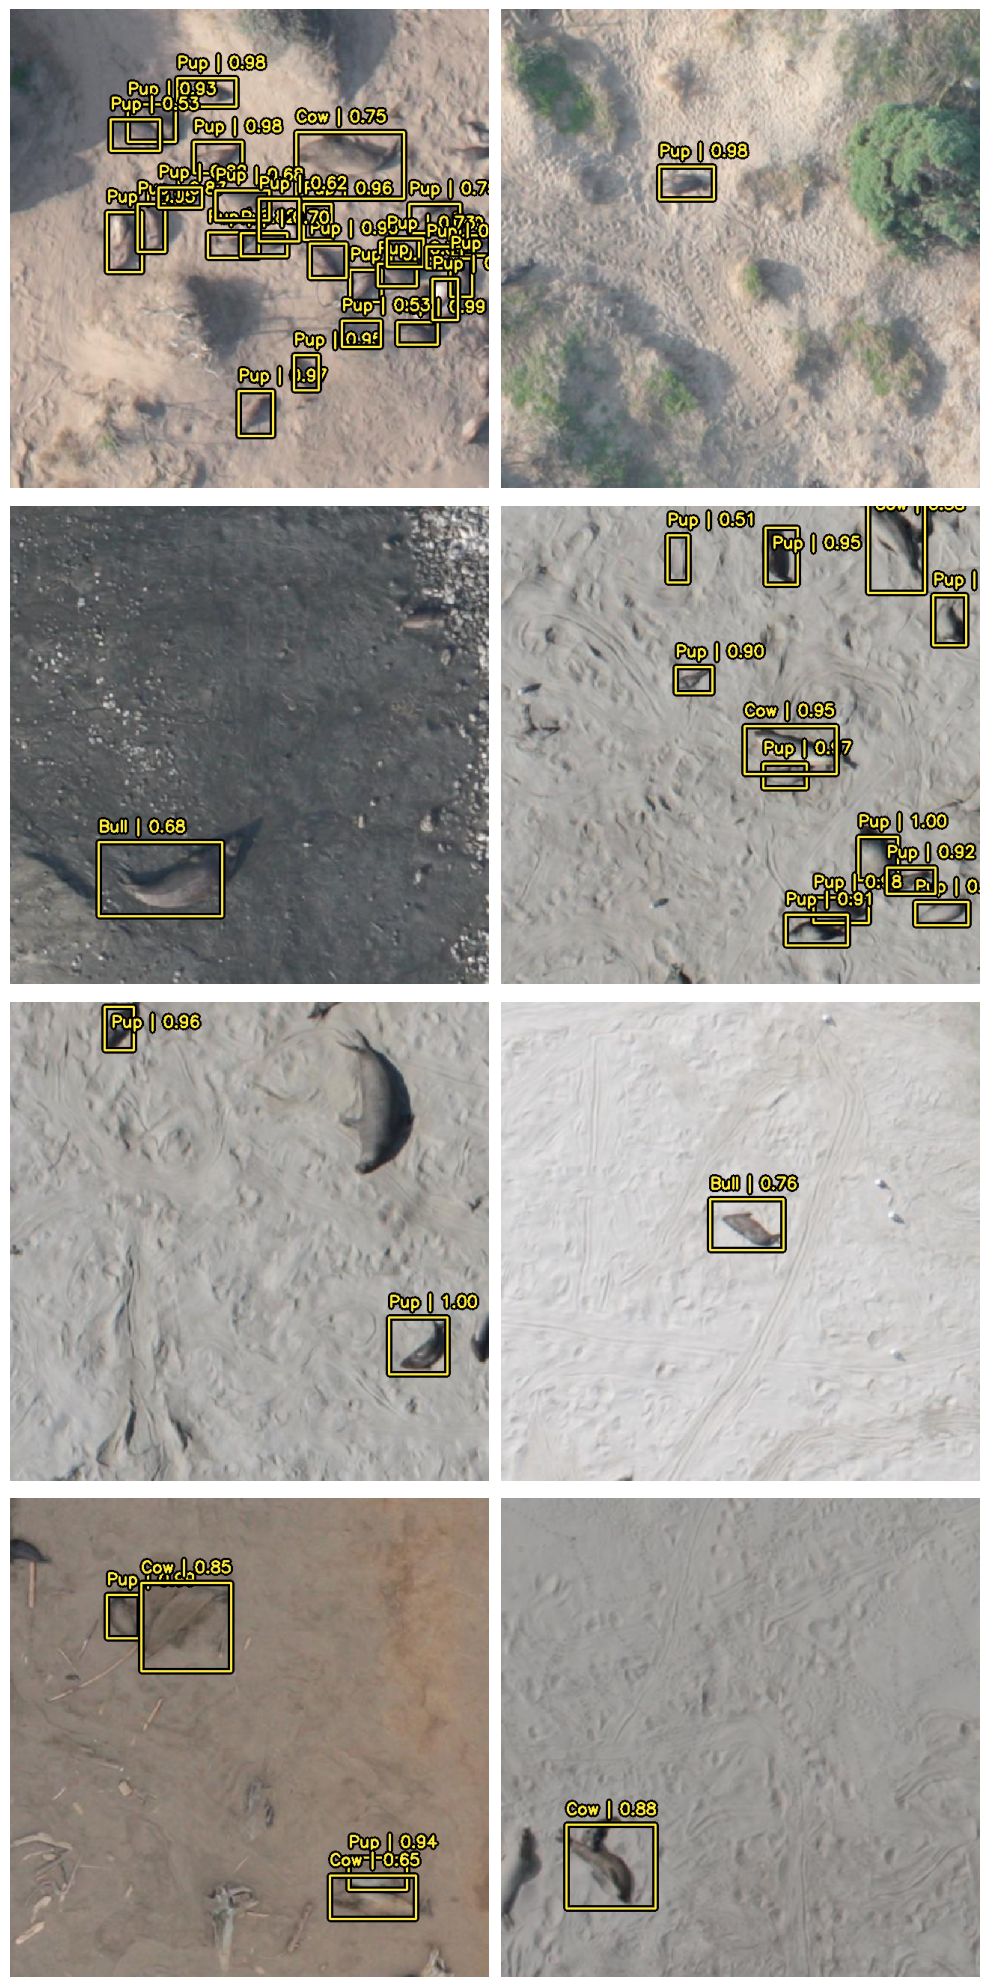

In [69]:
# 1. Prepare your images
# Assuming image_list is a list of paths or numpy arrays
# We need to resize them to the size the model expects (e.g., 640x640)
def load_and_prep(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(640, 640))
    return tf.keras.utils.img_to_array(img)

images = np.array([load_and_prep(img) for img in full_image_list_paths])

# NonMaxSuppression
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,           # RetinaNet usually outputs raw logits
    iou_threshold=0.3,          # Lower = stricter (fewer overlaps allowed)
    confidence_threshold=0.4,   # Your 0.4 threshold from before
)

# 2. Run Inference
# The model returns a dict with 'boxes' and 'classes'
predictions = model.predict(images)

# 3. Define your class mapping for the legend
# Ensure this matches your training IDs
class_mapping = {0: "Bull", 1: "Cow", 2: "Pup"}

# 4. Filter Detections by confidence
threshold = 0.5

# Extract predictions
# KerasCV prediction dict usually contains 'boxes', 'classes', and 'confidence'
boxes = predictions['boxes']
classes = predictions['classes']
confidences = predictions['confidence']

# 3. Create a mask for high-confidence detections
# This creates a boolean array where True means confidence > 0.4
mask = confidences > threshold

# 4. Apply the mask
# We fill low-confidence boxes with -1 (sentinel value) so the plotter ignores them
filtered_boxes = tf.where(tf.expand_dims(mask, -1), boxes, -1.0)
filtered_classes = tf.where(mask, tf.cast(classes, tf.int32), -1) # Ensure classes are int32

# 5. Reconstruct the prediction dict for the plotter
filtered_predictions = {
    'boxes': filtered_boxes,
    'classes': filtered_classes,
    'confidence': confidences
}

# 5. Plot the results
keras_cv.visualization.plot_bounding_box_gallery(
    images,
    value_range=(0, 255),
    rows=4,
    cols=2, 
    y_pred=filtered_predictions,
    bounding_box_format="xywh", 
    scale=5,
    font_scale=0.7,
    line_thickness=2,
    class_mapping=class_mapping,
)

plt.show()